<a href="https://colab.research.google.com/github/meharalirajar060-codeee/Flyrank_Internship_ML_MAR/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meharalirajar060-codeee/Flyrank_Internship_ML_MAR/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import duckdb, os, json
from google.colab import userdata

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
hf_token = userdata.get('HF_TOKEN')
con.execute(f"""CREATE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');""")
FACT = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet"

data = con.execute(f"""
    WITH march AS (
        SELECT content_hash_id, client_hash_id,
               SUM(gsc_impressions) AS impressions_90d,
               SUM(gsc_clicks) AS clicks_90d,
               AVG(gsc_avg_position) AS avg_position_90d,
               DATE_DIFF('day', MAX(report_date), DATE '2026-03-31') AS days_since_last_seen
        FROM read_parquet('{FACT}')
        WHERE month = '2026-03'
        GROUP BY content_hash_id, client_hash_id
        HAVING SUM(gsc_impressions) >= 100
    ),
    april AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS impressions_april
        FROM read_parquet('{FACT}') WHERE month = '2026-04' GROUP BY content_hash_id
    )
    SELECT m.*, COALESCE(a.impressions_april, 0) AS impressions_april
    FROM march m LEFT JOIN april a ON m.content_hash_id = a.content_hash_id
""").df()
data["ctr_90d"] = data["clicks_90d"] / data["impressions_90d"]
data["is_declining_label"] = (data["impressions_april"] < data["impressions_90d"] * 0.9).astype(int)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

features = ["impressions_90d", "clicks_90d", "avg_position_90d", "ctr_90d", "days_since_last_seen"]
X = data[features].fillna(0)
y = data["is_declining_label"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=data["client_hash_id"]))
model = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
model.fit(X.iloc[train_idx], y.iloc[train_idx])
print("Model ready.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model ready.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
"""Ranked actions: pages are scored by the Random Forest from ML-08, then mapped to one of four reason codes: stale_high_risk (refresh), model_flagged_risk (review_for_refresh), ctr_gap_visible (review_metadata), monitor_low_priority (monitor). This mirrors ML-07's baseline reason-code approach but replaces the fixed weighted score with the validated model's probability, informed by ML-09's honest client-holdout metrics rather than the inflated naive-split numbers."""

"Ranked actions: pages are scored by the Random Forest from ML-08, then mapped to one of four reason codes: stale_high_risk (refresh), model_flagged_risk (review_for_refresh), ctr_gap_visible (review_metadata), monitor_low_priority (monitor). This mirrors ML-07's baseline reason-code approach but replaces the fixed weighted score with the validated model's probability, informed by ML-09's honest client-holdout metrics rather than the inflated naive-split numbers."

In [3]:
data["model_score"] = model.predict_proba(X)[:, 1]

def reason_code(row):
    if row["model_score"] >= 0.65 and row["days_since_last_seen"] >= 30:
        return "stale_high_risk"
    elif row["model_score"] >= 0.65:
        return "model_flagged_risk"
    elif row["ctr_90d"] < data["ctr_90d"].median() and row["impressions_90d"] >= 500:
        return "ctr_gap_visible"
    else:
        return "monitor_low_priority"

data["reason_code"] = data.apply(reason_code, axis=1)

action_map = {
    "stale_high_risk": "refresh",
    "model_flagged_risk": "review_for_refresh",
    "ctr_gap_visible": "review_metadata",
    "monitor_low_priority": "monitor",
}
data["action"] = data["reason_code"].map(action_map)

ranked_queue = data.sort_values("model_score", ascending=False)
print(ranked_queue[["content_hash_id", "model_score", "reason_code", "action"]].head(20))

                content_hash_id  model_score         reason_code  \
93607  content_35ddcd760c64da18     0.723035  model_flagged_risk   
41514  content_a5e1a1f3b30597bf     0.720215  model_flagged_risk   
27173  content_502ad65d0b770851     0.714550  model_flagged_risk   
77754  content_aebfe5207a01df69     0.711795  model_flagged_risk   
11381  content_b9b75ec457ee78c7     0.710358  model_flagged_risk   
62818  content_c09209aa60aea972     0.708531  model_flagged_risk   
88295  content_17cb73582ac8a3e0     0.707698  model_flagged_risk   
72526  content_08f5a9b5810587ce     0.707003  model_flagged_risk   
27351  content_eb083d548c0bfe7d     0.706965  model_flagged_risk   
80376  content_cd4e5e7a4c5d80fb     0.706599  model_flagged_risk   
62491  content_a006cb27a7b948b7     0.706527  model_flagged_risk   
1042   content_866c0fa52cbb1271     0.706066  model_flagged_risk   
83137  content_907a75fcd9b4a100     0.706016  model_flagged_risk   
28465  content_d1a3abe6dca046b6     0.705789  mo

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
"""Intended use: this playbook is decision-support for a human content reviewer with limited capacity — it ranks candidates for review, it does not decide or execute any refresh itself.

Limits: (1) trained on one month's forward-window label (March->April) from one client-holdout split — not validated across multiple months or seasons; (2) days_since_last_seen showed zero feature importance in ML-08 because nearly all pages were active on the window's last day — staleness signal is currently weak in this feature set; (3) AUC was modest (0.53-0.59 per ML-09), meaning the model's ranking is a directional signal, not a confident probability; (4) cannot distinguish real decline from consolidation, seasonality, or SERP feature changes — a human reviewer must rule these out per the lane guide's Section 7 checklist before acting."""

"Intended use: this playbook is decision-support for a human content reviewer with limited capacity — it ranks candidates for review, it does not decide or execute any refresh itself.\n\nLimits: (1) trained on one month's forward-window label (March->April) from one client-holdout split — not validated across multiple months or seasons; (2) days_since_last_seen showed zero feature importance in ML-08 because nearly all pages were active on the window's last day — staleness signal is currently weak in this feature set; (3) AUC was modest (0.53-0.59 per ML-09), meaning the model's ranking is a directional signal, not a confident probability; (4) cannot distinguish real decline from consolidation, seasonality, or SERP feature changes — a human reviewer must rule these out per the lane guide's Section 7 checklist before acting."

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
"""Human review is required before any action in this queue is executed. Reviewers should check: is this consolidation (a sibling URL absorbing traffic)? Is this seasonal? Did a SERP feature change eat the clicks rather than a content problem?

NOT to be automated, ever:
- Automatic publishing or deleting of content based on this score alone
- Automatic reallocation of budget or team time without a human sign-off
- Any external-facing claim that a page 'will' decline or recover — the model output is a ranked probability, not a guarantee
- Treating monitor_low_priority pages as 'safe' with certainty — low score means lower estimated risk, not zero risk"""

"Human review is required before any action in this queue is executed. Reviewers should check: is this consolidation (a sibling URL absorbing traffic)? Is this seasonal? Did a SERP feature change eat the clicks rather than a content problem?\n\nNOT to be automated, ever:\n- Automatic publishing or deleting of content based on this score alone\n- Automatic reallocation of budget or team time without a human sign-off\n- Any external-facing claim that a page 'will' decline or recover — the model output is a ranked probability, not a guarantee\n- Treating monitor_low_priority pages as 'safe' with certainty — low score means lower estimated risk, not zero risk"

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
"""Light monitoring plan: re-score monthly as new fact_content_daily_performance data lands. Retrain triggers: (1) if the client mix changes significantly (new clients added/removed, since the model was validated on a specific 35/9 train/test client split); (2) if Precision@50 on a fresh held-out month drops meaningfully below the ML-09 baseline (0.64) — a sign the model's signal has drifted; (3) at minimum quarterly, since this is only validated on one month-pair (March->April) and search behavior can shift seasonally."""


"Light monitoring plan: re-score monthly as new fact_content_daily_performance data lands. Retrain triggers: (1) if the client mix changes significantly (new clients added/removed, since the model was validated on a specific 35/9 train/test client split); (2) if Precision@50 on a fresh held-out month drops meaningfully below the ML-09 baseline (0.64) — a sign the model's signal has drifted; (3) at minimum quarterly, since this is only validated on one month-pair (March->April) and search behavior can shift seasonally."

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


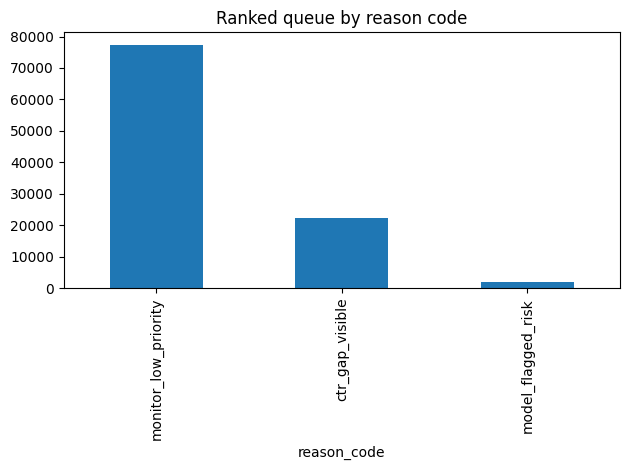

Exported queue, metrics JSON, and figure.


In [9]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

metrics = {
    "model": "random_forest",
    "validation_split": "client_holdout",
    "auc": 0.580,
    "avg_precision": 0.615,
    "precision_at_50": 0.64,
    "naive_split_auc_for_comparison": 0.626,
    "naive_split_precision_at_50": 0.78,
    "baseline_rule_precision_at_50": 0.64,
    "n_train_clients": 35,
    "n_test_clients": 9,
}
with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
top_reason_counts = ranked_queue["reason_code"].value_counts()
top_reason_counts.plot(kind="bar", title="Ranked queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png")
plt.show()

print("Exported queue, metrics JSON, and figure.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.